# DDM toy fit — parameter recovery

**This notebook uses only synthetic data.** No real Stroop data has been collected yet (see `DECISIONS.md`, 2026-08-25) — the point here is exclusively to validate that the PyDDM fitting pipeline works end-to-end *before* trusting it with real data.

The dataset is generated by actually sampling from a DDM with known ("true") parameters: drift rate differs between the congruent/incongruent conditions, but threshold (boundary separation) is identical across both, on purpose. This lets us check that the fit correctly attributes the simulated effect to drift rate and not to a spurious threshold difference — the standard "parameter recovery" sanity check for a DDM pipeline.

All fitting logic lives in `driftlab_analysis.ddm` — this notebook only orchestrates and visualizes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from driftlab_analysis.ddm import fit_ddm_by_condition
from driftlab_analysis.simulate import (
    DDM_TOY_BOUND,
    DDM_TOY_DRIFT_CONGRUENT,
    DDM_TOY_DRIFT_INCONGRUENT,
    DDM_TOY_NONDECISION_S,
    simulate_stroop_ddm_toy,
)

## Generate the toy dataset

In [2]:
df = simulate_stroop_ddm_toy()
print(df.shape)
print(df["congruency"].value_counts())
df.head()

(400, 8)
congruency
congruent      200
incongruent    200
Name: count, dtype: int64


,participant_id,task,block,trial_index,rt,correct,timestamp,congruency
0,ddm-toy-00000042,stroop_ddm_toy,test,0,1025.5,1,2026-01-01T00:00:00+00:00,congruent
1,ddm-toy-00000042,stroop_ddm_toy,test,1,677.6,1,2026-01-01T00:00:03+00:00,congruent
2,ddm-toy-00000042,stroop_ddm_toy,test,2,741.6,1,2026-01-01T00:00:06+00:00,congruent
3,ddm-toy-00000042,stroop_ddm_toy,test,3,785.2,1,2026-01-01T00:00:09+00:00,congruent
4,ddm-toy-00000042,stroop_ddm_toy,test,4,695.8,1,2026-01-01T00:00:12+00:00,congruent


## Fit a DDM per condition

In [3]:
fitted = fit_ddm_by_condition(df, seed=123)
fitted

Info: Params [2.44537675 1.12239135 0.28260578] gave -2.580332395573727


Info: Params [1.41194378 0.94785264 0.32697605] gave 98.95731407401044


{'congruent': {'drift_rate': 2.445376747478798,
  'threshold': 1.1223913469786662,
  'non_decision_time': 0.28260577886035954},
 'incongruent': {'drift_rate': 1.4119437775751502,
  'threshold': 0.9478526421786584,
  'non_decision_time': 0.32697605080315784}}

## Parameter recovery: true vs. fitted

If the pipeline is working, fitted values should land close to the true generative parameters, and (critically) the drift rate difference between conditions should be recovered while threshold stays roughly equal.

In [4]:
true_params = {
    "congruent": {
        "drift_rate": DDM_TOY_DRIFT_CONGRUENT,
        "threshold": DDM_TOY_BOUND,
        "non_decision_time": DDM_TOY_NONDECISION_S,
    },
    "incongruent": {
        "drift_rate": DDM_TOY_DRIFT_INCONGRUENT,
        "threshold": DDM_TOY_BOUND,
        "non_decision_time": DDM_TOY_NONDECISION_S,
    },
}

print(f"{'condition':<13} {'parameter':<20} {'true':>8} {'fitted':>8}")
for condition in ("congruent", "incongruent"):
    for param in ("drift_rate", "threshold", "non_decision_time"):
        print(
            f"{condition:<13} {param:<20} "
            f"{true_params[condition][param]:>8.3f} {fitted[condition][param]:>8.3f}"
        )

condition     parameter                true   fitted
congruent     drift_rate              2.000    2.445
congruent     threshold               1.000    1.122
congruent     non_decision_time       0.300    0.283
incongruent   drift_rate              1.200    1.412
incongruent   threshold               1.000    0.948
incongruent   non_decision_time       0.300    0.327


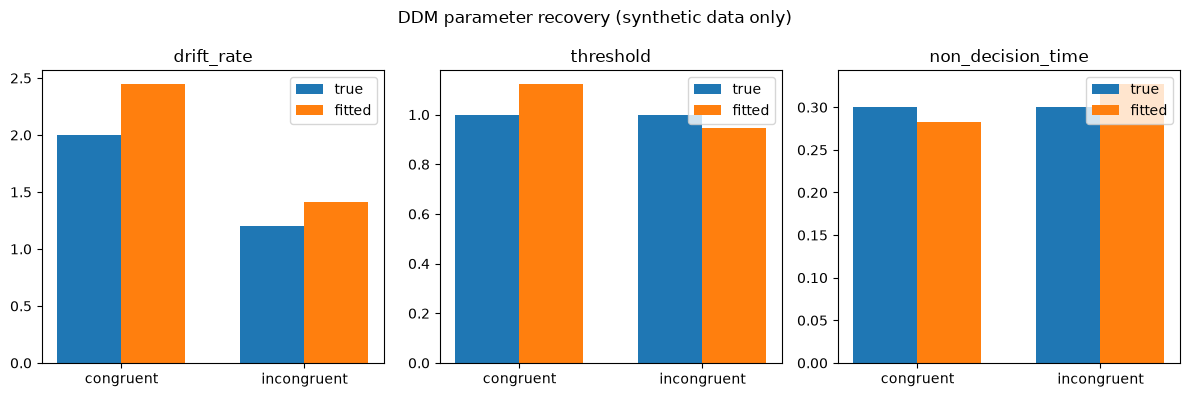

In [5]:
params = ["drift_rate", "threshold", "non_decision_time"]
conditions = ["congruent", "incongruent"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, param in zip(axes, params):
    x = np.arange(len(conditions))
    true_vals = [true_params[c][param] for c in conditions]
    fitted_vals = [fitted[c][param] for c in conditions]
    width = 0.35
    ax.bar(x - width / 2, true_vals, width, label="true")
    ax.bar(x + width / 2, fitted_vals, width, label="fitted")
    ax.set_xticks(x)
    ax.set_xticklabels(conditions)
    ax.set_title(param)
    ax.legend()

fig.suptitle("DDM parameter recovery (synthetic data only)")
plt.tight_layout()
plt.show()